# Статистика, DS-поток
## Блиц-домашка SB.8

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание.**

* Задача 1 &mdash; 10 баллов;
* Задача 2 &mdash; 15 баллов;
* Задача 3 &mdash; 20 баллов;
* Задача 4 &mdash; 30 баллов.

**Важность задач:**

* *высокая:* задачи 1-4



In [ ]:
# Bot check

# HW_ID: ds_sb8
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [14]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
# sns.set(style='whitegrid', font_scale=1.3, palette='Set2')

sns.set(style="whitegrid", font_scale=1.3, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])
from statsmodels.stats.multitest import multipletests

In [29]:
import base64
from IPython.display import Markdown, display
def embed_image(filename):
    with open(filename, "rb") as f:
        data = base64.b64encode(f.read()).decode()
    md = f'<img src="data:image/png;base64,{data}" width="800">'
    display(Markdown(md))

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована

_____
### Задача 1
Были проведены эксперименты для оценки эффективности нескольких препаратов для снижения послеоперационной тошноты. Результаты экспериментов приведены в таблице ниже. При проведении эксперимента пациенты делились на группы случайным образом.




|| Количество пациентов   | Количество случаев возникновения тошноты |
|-----------| ----------- | -------|
|Плацебо|80|45|
|Хлорпромазин|75|26|
|Дименгидринат|85|52|
|Пентобарбитал (100 мг)|67|35|
|Пентобарбитал (150 мг)|85|37|




Проведите сравнение каждого препарата по эффективности по отношению к плацебо. Какие ответы можно получить для методов, контролирующих FWER и FDR? В каждом случае приведите скорректированные p-value.

*Замечание.* Используйте [`multipletests`](https://www.statsmodels.org/dev/generated/statsmodels.stats.multitest.multipletests.html) из библиотеки `statsmodels`. 

**Решение:** 

In [25]:
p1 = sps.binom(n=80, p=0.5).cdf(45)
p2 = sps.binom(n=75, p=0.5).cdf(26)
p3 = sps.binom(n=85, p=0.5).cdf(52)
p4 = sps.binom(n=67, p=0.5).cdf(35)
p5 = sps.binom(n=85, p=0.5).cdf(37)

pvals = [p1, p2, p3, p4, p5]
print('Независимые p-value:', *pvals)

reject, pvals_corrected, _, _ = multipletests(pvals, method='bonferroni')
print('Резльтаты множественной проверки гипотез методом Бонферрони (FWER):', *reject)
print('Скорректированные p-value:', *pvals_corrected)

reject, pvals_corrected, _, _ = multipletests(pvals, method='fdr_by')
print('Резльтаты множественной проверки гипотез методом Бенджамини-Иекутиелли (FDR):', *reject)
print('Скорректированные p-value:', *pvals_corrected)

Независимые p-value: 0.8907409802606481 0.005291058525852635 0.9852718191071106 0.6872965855291758 0.13899964454027586
Резльтаты множественной проверки гипотез методом Бонферрони (FWER): False True False False False
Скорректированные p-value: 1.0 0.026455292629263175 1.0 1.0 0.6949982227013793
Резльтаты множественной проверки гипотез методом Бенджамини-Иекутиелли (FDR): False False False False False
Скорректированные p-value: 1.0 0.06040625150348425 1.0 1.0 0.7934563042507413


**Вывод:** Так как $FDR \le FWER$, то там, где FWER уже отвергает, FDR ещё может и не отвергнуть, поэтому, как видим из теста выше, метод, использующий FWER для МПГ отверг вторую гипотезу, а FDR не отверг никакую

В данном случае мы используем статистики от независимо сгенерированных выборок, поэтому используемая статистика суммы случайных величин также независима, можно применить метож Бенджамини-Хохберга. Также посмотрим на метод Холма

In [27]:
reject, pvals_corrected, _, _ = multipletests(pvals, method='holm')
print('Резльтаты множественной проверки гипотез методом Холма (FWER):', *reject)
print('Скорректированные p-value:', *pvals_corrected)

reject, pvals_corrected, _, _ = multipletests(pvals, method='fdr_bh')
print('Резльтаты множественной проверки гипотез методом Бенджамини-Хохберга (FDR):', *reject)
print('Скорректированные p-value:', *pvals_corrected)

Резльтаты множественной проверки гипотез методом Холма (FWER): False True False False False
Скорректированные p-value: 1.0 0.026455292629263175 1.0 1.0 0.5559985781611034
Резльтаты множественной проверки гипотез методом Бенджамини-Хохберга (FDR): False True False False False
Скорректированные p-value: 0.9852718191071106 0.026455292629263175 0.9852718191071106 0.9852718191071106 0.3474991113506896


Метод Холма мощнее Бонеррони, но отверг так же только ту же самую гипотезу. Метод Бенджамини-Хохберга оказался мощнее Бенджамини-Иекутиелли, потому что он эту же самую гипотезу отверг, хотя тоже контроллирует FDR

---
### Задача 2

Выведите формулу коррекции p-value в методе Бенджамини-Иекутиели.

Запишем пограничный случай:

$$
p_{(j)} \le \frac{\alpha j}{m \sum_{i=1}^{m} \frac{1}{i}}, 
\quad 
\tilde{p}_{(j)} \le \alpha
\;\Rightarrow\;
\tilde{p}_{(j)} = \frac{m p_{(j)} \sum_{i=1}^{m} \frac{1}{i}}{j}
$$

&nbsp;&nbsp;&nbsp;&nbsp;Далее учтём, что все гипотезы, чей $p$-value оказался меньше, мы должны отвергнуть.  
Для этого скорректированный $p$-value должен всё время уменьшаться по мере выполнения процедуры.  
Поэтому возьмём:

$$
\tilde{p}_{(j)} = 
\min\left(
\tilde{p}_{(j-1)},\,
\frac{m p_{(j)} \sum_{i=1}^{m} \frac{1}{i}}{j}
\right)
$$

&nbsp;&nbsp;&nbsp;&nbsp;Далее $p$-value не может быть больше единицы, поэтому окончательная форма:

$$
\tilde{p}_{(j)} =
\min\!\left(
\min\!\left(
\tilde{p}_{(j-1)},\,
\frac{m p_{(j)} \sum_{i=1}^{m} \frac{1}{i}}{j}
\right),
1
\right)
$$




---
### Задача 3

Пусть $X_j = (X_{j1}, ..., X_{jn}), j\in\{1, 2\}, X_1 = X_2$ &mdash; две одинаковые выборки из распределения $\Gamma(\theta, \beta)$, причем $\beta$ известно. Основные гипотезы $\mathsf{H}_j$ одинаковы: $\mathsf{H}_j\colon \theta=\theta_0$, а в качестве альтернатив рассматриваются левосторонняя и правосторонняя. Для каждой альтернативы построен соответствующий РМНК. Чему равен FWER? Постройте критерий для отвержения основной гипотезы, используя метод Бонферонни.
    
*Замечание.* Это только хорошая учебная задача, на практике стоит рассматривать двустороннюю альтернативу. Обратите внимание на предыдущие домашние задания и семинар.

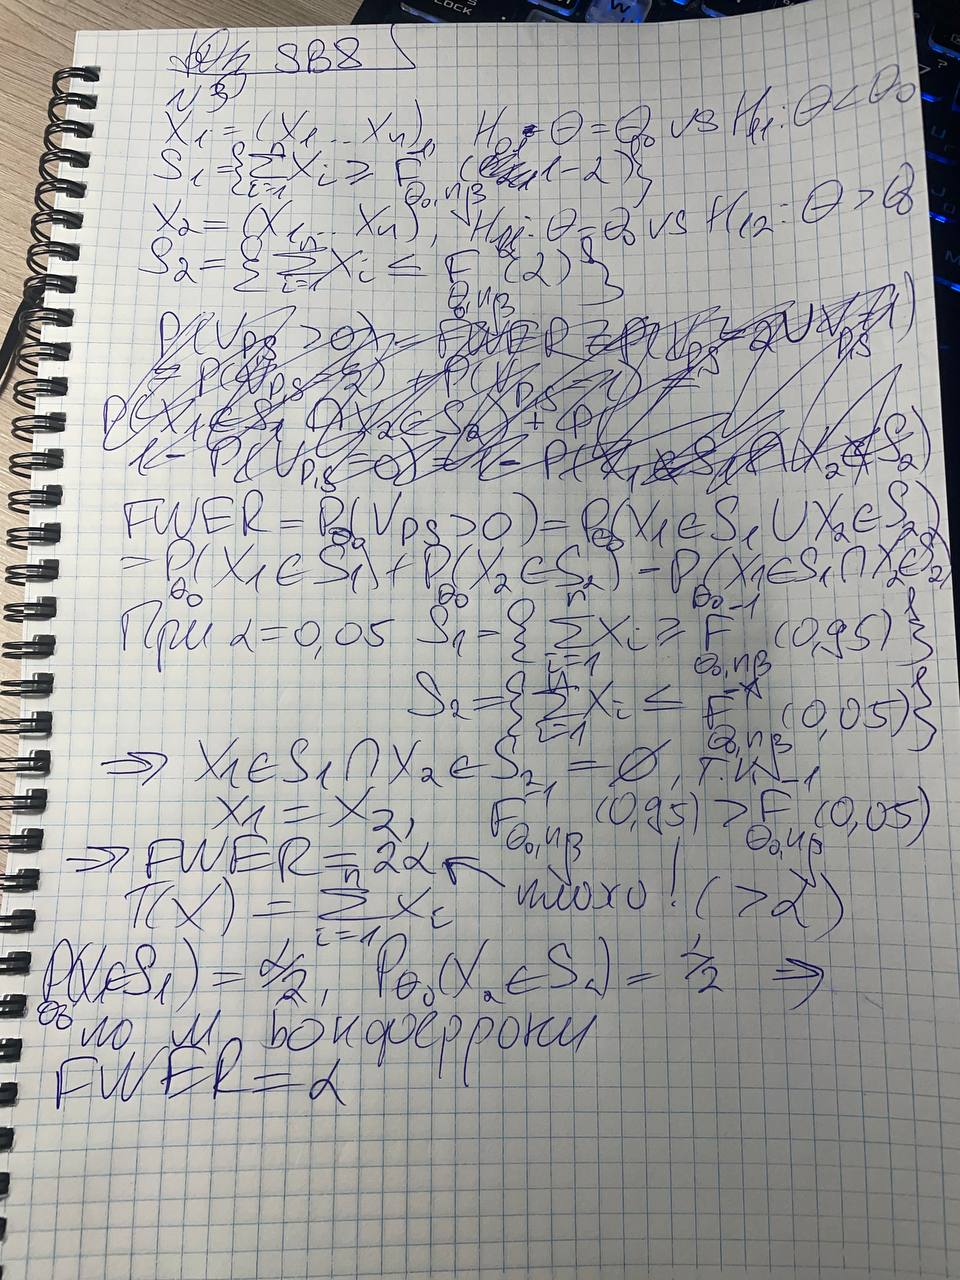

In [30]:
embed_image('1.jpg')

---
### Задача 4


Проверяются гипотезы $\mathsf{H}_1$ и $\mathsf{H}_2$ критериями $S_1$ и $S_2$ соответственно. Приведите пример, при котором значение FWER при справедливости обеих гипотез $\mathsf{H}_1$ и $\mathsf{H}_2$ меньше, чем при справедливости только одной из них.
    
*Замечание.* Возможно, проще рассмотреть случай конечного $\mathscr{X}$.

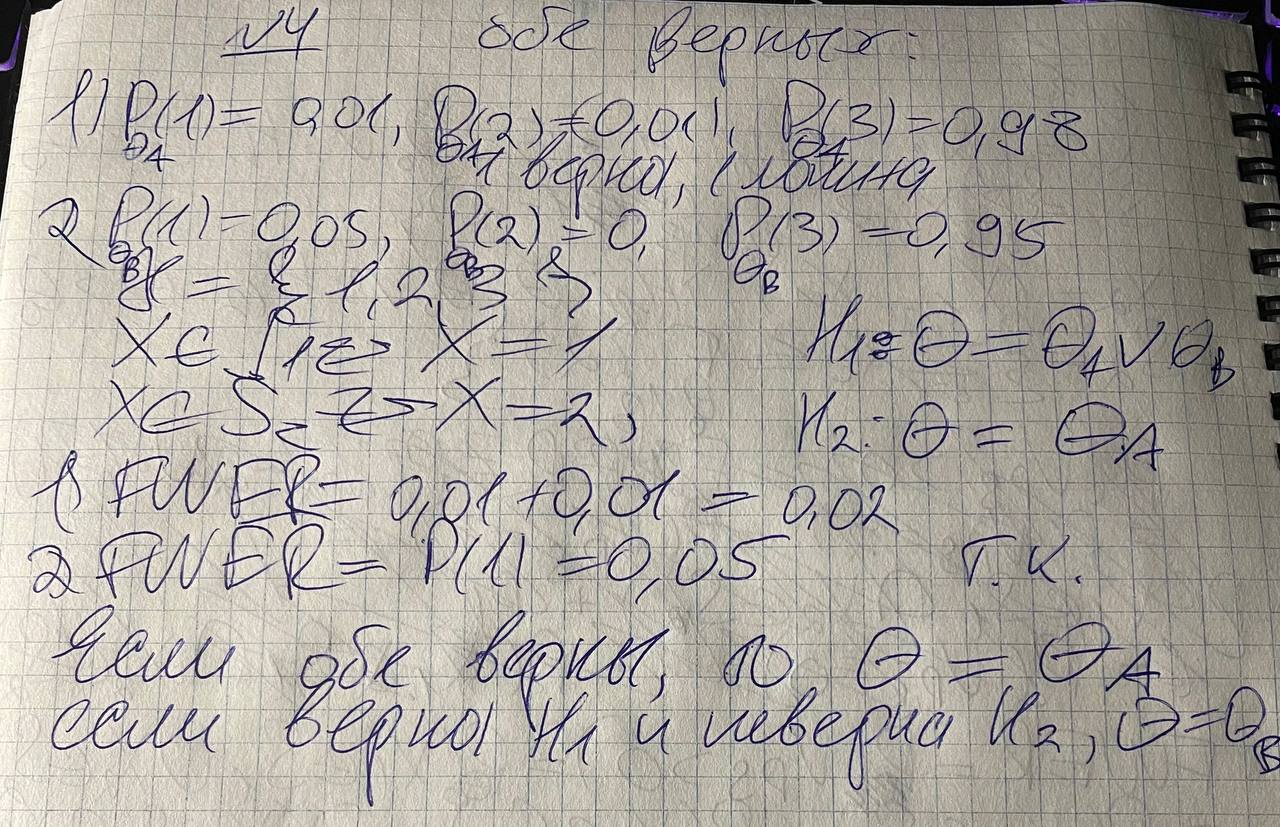

In [31]:
embed_image('2.jpg')

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока